# Multiple FFT

In [1]:
from numpy import fft as fft
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import lmfit
from lmfit.models import GaussianModel, LorentzianModel, LinearModel
from lmfit import Model
from lmfit import conf_interval, conf_interval2d, report_ci

# find_pulse_end

In [2]:
def find_pulse_end(signal, threshold_max, threshold_min):
  trigger = False
  print(signal[4])
  print(signal)
  for i in range(len(signal)):
    if (signal[i] > threshold_max):
      trigger = True
    if (trigger == True and signal[i] < threshold_min):
      return(i)
  return(0)

# chop_signal

In [3]:
def chop_signal(signal, start):
  return(signal[start:])

# get_fft_from_FID

In [4]:
def get_fft_from_FID(fft_df, threshold_max, threshold_min):
    time = fft_df['time']
    ch1 = fft_df['channel_1']

    # print(type(ch1))

    print("This is the raw FID plot\n")
    plt.plot(time, ch1)
    # plt.show()

    chop_point = find_pulse_end(ch1, 7.5, 6) 
    chopped_ch1 = chop_signal(ch1,chop_point)
    chopped_time = chop_signal(time, chop_point)

    print("this is the chopped plot\n")

    plt.plot(chopped_time, chopped_ch1)
    plt.show()

    chopped_ch1 = chopped_ch1.tolist()

    # print(chopped_ch1)

    ch1_fft = fft.rfft(chopped_ch1)
    freqs = fft.rfftfreq(len(chopped_ch1), d=time[1]-time[0])


    return freqs, ch1_fft

# txt_fit_report

In [5]:
def txt_fit_report(filename, report):
    with open(filename, "w") as f:
        f.write("Fit Report for Hydrogen Peak in Mineral Oil\n")
        f.write("="*50 + "\n")
        f.write(report)

# plot_FID

# get_filenames

In [6]:

from pathlib import Path

def get_filenames(folder_path, extension=None):
    """
    Returns:
    1. A list of absolute PATHS for the original files.
    2. A list of FILENAMES (strings) for the corresponding [filename]_out.txt.
    """
    path = Path(folder_path).resolve()
    
    if not path.is_dir():
        return [], []

    # Get the source file objects
    if extension:
        files = list(path.glob(f"*{extension}"))
    else:
        files = [f for f in path.iterdir() if f.is_file()]

    # Original paths: Full absolute location
    original_paths = [str(f) for f in files]
    
    # Output names: Just the filename string with the suffix added
    output_names = [f"{f.name}_out.txt" for f in files]

    return original_paths, output_names

# get_fourier_freq

This is the raw FID plot

0.08
0       0.00
1       0.00
2       0.00
3       0.00
4       0.08
        ... 
2494   -0.08
2495    0.00
2496    0.00
2497    0.00
2498    0.00
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



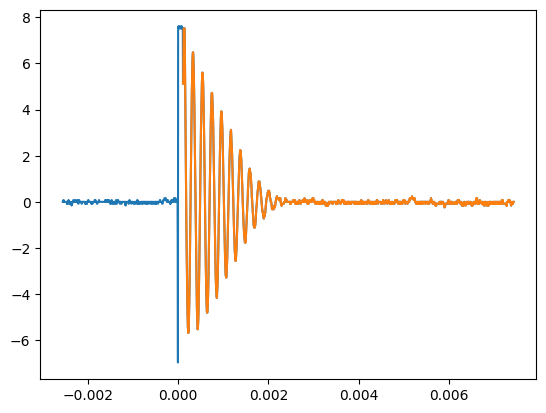

## Confidence Report:
Frequency is at 4786.367581187583 Hz


{'max_freq': 4786.367581187583,
 'max_power': np.float64(765906.4381246517),
 'result': <lmfit.model.ModelResult at 0x1dfd9d19a90>,
 'eval': array([-9.12653711e+03, -9.10210683e+03, -9.07753021e+03, -9.05280563e+03,
        -9.02793140e+03, -9.00290584e+03, -8.97772724e+03, -8.95239386e+03,
        -8.92690394e+03, -8.90125569e+03, -8.87544729e+03, -8.84947692e+03,
        -8.82334269e+03, -8.79704272e+03, -8.77057509e+03, -8.74393786e+03,
        -8.71712904e+03, -8.69014663e+03, -8.66298859e+03, -8.63565287e+03,
        -8.60813737e+03, -8.58043996e+03, -8.55255849e+03, -8.52449077e+03,
        -8.49623457e+03, -8.46778765e+03, -8.43914771e+03, -8.41031243e+03,
        -8.38127945e+03, -8.35204638e+03, -8.32261080e+03, -8.29297023e+03,
        -8.26312217e+03, -8.23306409e+03, -8.20279338e+03, -8.17230745e+03,
        -8.14160362e+03, -8.11067919e+03, -8.07953142e+03, -8.04815753e+03,
        -8.01655467e+03, -7.98471998e+03, -7.95265053e+03, -7.92034336e+03,
        -7.88779545e+03,

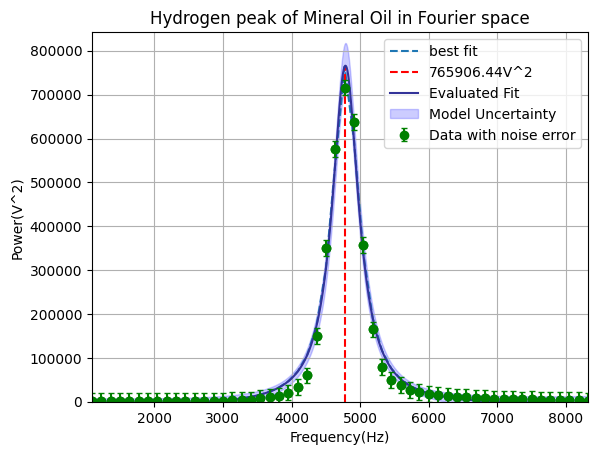

In [40]:
filename = "2.10 Data Sample 2/FIDs/Sample2_FID_freq6487930.csv"
out_filename = "fit_Sample2_FID_freq6485930.txt"
pulse_params= {"threshold_max":7.5, "threshold_min":6}
fft_params = {"initial_sigma": 5000, "num_points": 700, "sigma_levels": [1,2,3]}

def get_fourier_freq(filename, out_filename, pulse_params, fft_params, i_offset=30, plot=True):

    # Read the data into a dataframe

    # print(filename)
    fft_df = pd.DataFrame()
    fft_df = pd.read_csv(filename)
    cols = ['time', 'channel_1','channel_2']
    fft_df.columns = cols
    # fft_t2_df.head()

    # #Plot the FID
    # time = fft_t2_df['time']
    # ch1 = fft_t2_df['channel_1']

    freqs, ch1_fft = get_fft_from_FID(fft_df, pulse_params["threshold_max"], pulse_params["threshold_min"])
    
    

    # # Cut out the pulse
    # chop_point = find_pulse_end(ch1, 
    #                             pulse_params["threshold_max"], 
    #                             pulse_params["threshold_min"]) 
    # chopped_ch1 = chop_signal(ch1,chop_point) 
    # chopped_time = chop_signal(time, chop_point) 

    # if plot==True:
    #     plt.plot(time, ch1)
    #     plt.plot(chopped_time, chopped_ch1)
    #     plt.grid()
    #     plt.show()

    # # chopped_time, chopped_ch1 = plot_FID(filename)

    # # Apply fourier transform
    # print(type(chopped_ch1))

    

    # ch1_fft = fft.rfft(chopped_ch1)
    # freqs = fft.rfftfreq(len(chopped_ch1), d=time[1]-time[0])


    # we are looking at freqs vs power
    power = np.abs(ch1_fft)**2

    # get initial guess of peak and index it occurs at
    
    maxi = np.argmax(power, axis=0)

    raw_points = len(freqs)

    start_i = maxi - int(i_offset*raw_points)
    end_i = maxi + int(i_offset*raw_points)

    if start_i < 0:
        start_i = 0

    power=power[start_i: end_i]
    freqs=freqs[start_i: end_i]

    maxval = np.max(power, axis=0)
    maxi = np.argmax(power, axis=0)


    max_freq = freqs[maxi]



    gmodel = LorentzianModel()+ LinearModel()
    initial_sigma = fft_params['initial_sigma']
    initial_amplitude = maxval * initial_sigma * np.sqrt(2 * np.pi)
    params = gmodel.make_params()
    params['slope'].set(value=-1) # Better guess for constant background
    params['amplitude'].set(value=initial_amplitude, min=0) 
    params['center'].set(value=max_freq, min=0)
    params['sigma'].set(value=initial_sigma, min=1e-3)



    # get the fit
    result = gmodel.fit(power,params, x= freqs)

    # evaluate fit at many freq values

    
    many_freqs = np.linspace(np.min(freqs),np.max(freqs), fft_params['num_points'])
    y_random_fit = result.eval(x=many_freqs)



    # get CIs of all the parameters
    # print(result.fit_report())
    sigma_levels = fft_params['sigma_levels']
    txt_fit_report(out_filename, result.fit_report())
    ci = conf_interval(result, result, sigmas=sigma_levels)


    # using evaluated fit get peak values
    new_maxval = np.max(y_random_fit, axis=0)
    # new_maxi = np.argmax(y_random_fit, axis=0)
    # new_max_freq = many_freqs[new_maxi]

    # new_maxval = result.params['amplitude'].value
    # new_maxi = np.argmax(y_random_fit, axis=0)
    new_max_freq = result.params['center'].value


    

    dely_random = result.eval_uncertainty(x=many_freqs, sigma=3)

    noise_sigma = result.residual.std()

    # plt.show()
    
    # plt.plot(freqs, many_result.best_fit, '-', label='best fit')



    if plot==True:
        plt.scatter(freqs, power, color = "green")
        plt.plot(freqs, result.best_fit, '--', label='best fit')
        plt.title("Hydrogen peak of Mineral Oil in Fourier space")
        plt.xlabel("Frequency(Hz)")
        plt.ylabel("Power(V^2)")
        # plt.plot(freqs, power)
        plt.vlines(new_max_freq, 0, new_maxval,colors="red", linestyles="--", label=f"{new_maxval:.2f}V^2")
        plt.plot(many_freqs, y_random_fit, color=(0.2,0.2,0.6), label='Evaluated Fit')
        # Add the confidence interval for the random points
        plt.fill_between(many_freqs, 
                        y_random_fit - dely_random, 
                        y_random_fit + dely_random, 
                        color="blue", alpha=0.2, label='Model Uncertainty')
        plt.errorbar(freqs, power, yerr=noise_sigma, fmt='o', 
                    color="green", ecolor='green', 
                    capsize=2, label='Data with noise error')
        plt.grid()
        plt.xlim(np.min(freqs), np.max(freqs) )
        plt.ylim(0,new_maxval*(1.1))
        plt.legend()
        
    print("## Confidence Report:")
    # report_ci(ci)

    print(f"Frequency is at {new_max_freq} Hz")

    return {'max_freq':new_max_freq, 'max_power':new_maxval, 'result': result, 'eval': y_random_fit, 'ci': ci}
        
get_fourier_freq(filename, out_filename, pulse_params, fft_params, i_offset=3e-2)      

# get_fft_data

In [48]:
def get_fft_data(sample, sampleout, pulse_params, fft_params, id='', plot=True):
    fft_list = []
    count = 0
    for filename in sample1:
        out_filename = "outdata/" + sampleout[count] + id
        fft_data = get_fourier_freq(filename, out_filename, pulse_params, fft_params, i_offset=3e-2, plot=plot)
        print(fft_data)
        fft_list.append(fft_data)
        count += 1
    return fft_list



# Sample 1

In [41]:
sample1filename = "pNMR 2.26 final data FID/SAMPLE1"
sample1, sample1out = get_filenames(sample1filename, extension='.csv')

# sample1_2filename = "pNMR2.5 FFT T2 data/Sick_aFIDS"
# sample1_2, sample1_2out = get_filenames(sample1_2filename, extension='.csv')

# sample1 = sample1 + sample1_2
# sample1out = sample1out + sample1_2out

# print(sample1)


### first sample 1

This is the raw FID plot

0.0
0       0.06
1       0.06
2       0.00
3       0.00
4       0.00
        ... 
2494    0.00
2495    0.00
2496   -0.06
2497   -0.06
2498   -0.06
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



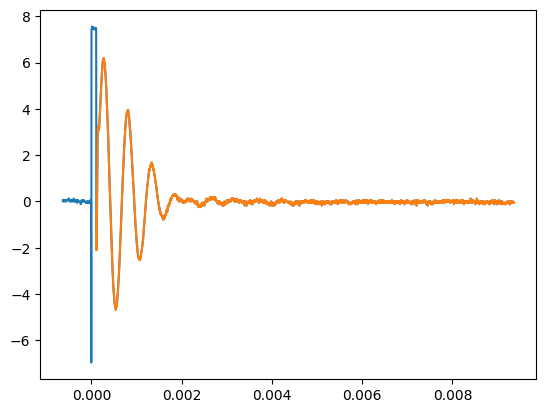

## Confidence Report:
Frequency is at 1816.6926656412513 Hz
{'max_freq': 1816.6926656412513, 'max_power': np.float64(468133.8378696291), 'result': <lmfit.model.ModelResult object at 0x000001DFD6EAF390>, 'eval': array([ 1.54690983e+04,  1.55358371e+04,  1.56037286e+04,  1.56727916e+04,
        1.57430451e+04,  1.58145086e+04,  1.58872020e+04,  1.59611456e+04,
        1.60363600e+04,  1.61128663e+04,  1.61906861e+04,  1.62698413e+04,
        1.63503544e+04,  1.64322484e+04,  1.65155466e+04,  1.66002728e+04,
        1.66864516e+04,  1.67741078e+04,  1.68632668e+04,  1.69539546e+04,
        1.70461978e+04,  1.71400235e+04,  1.72354594e+04,  1.73325337e+04,
        1.74312755e+04,  1.75317143e+04,  1.76338802e+04,  1.77378041e+04,
        1.78435177e+04,  1.79510531e+04,  1.80604434e+04,  1.81717222e+04,
        1.82849241e+04,  1.84000843e+04,  1.85172389e+04,  1.86364248e+04,
        1.87576797e+04,  1.88810421e+04,  1.90065517e+04,  1.91342489e+04,
        1.92641749e+04,  1.93963721e+04

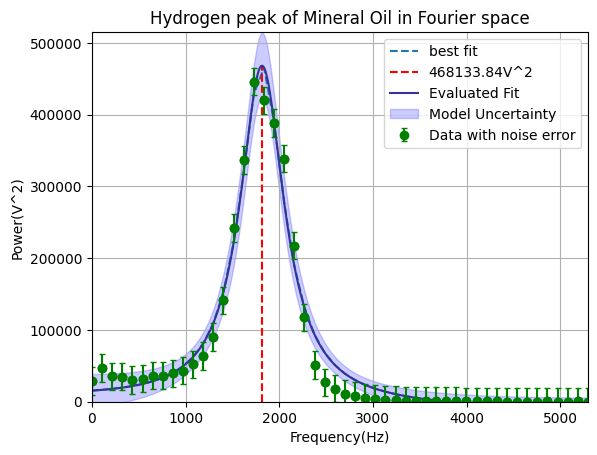

## Confidence Report:
Frequency is at 2706.438045905261 Hz
{'max_freq': 2706.438045905261, 'max_power': np.float64(489152.8880200373), 'result': <lmfit.model.ModelResult object at 0x000001DFDB1B0690>, 'eval': array([ 1.14668868e+05,  1.14497158e+05,  1.14325707e+05,  1.14154518e+05,
        1.13983594e+05,  1.13812939e+05,  1.13642557e+05,  1.13472451e+05,
        1.13302625e+05,  1.13133083e+05,  1.12963828e+05,  1.12794865e+05,
        1.12626197e+05,  1.12457829e+05,  1.12289765e+05,  1.12122008e+05,
        1.11954564e+05,  1.11787436e+05,  1.11620629e+05,  1.11454147e+05,
        1.11287996e+05,  1.11122179e+05,  1.10956702e+05,  1.10791568e+05,
        1.10626784e+05,  1.10462354e+05,  1.10298283e+05,  1.10134577e+05,
        1.09971240e+05,  1.09808278e+05,  1.09645697e+05,  1.09483502e+05,
        1.09321698e+05,  1.09160292e+05,  1.08999289e+05,  1.08838696e+05,
        1.08678517e+05,  1.08518761e+05,  1.08359432e+05,  1.08200538e+05,
        1.08042085e+05,  1.07884079e+05, 

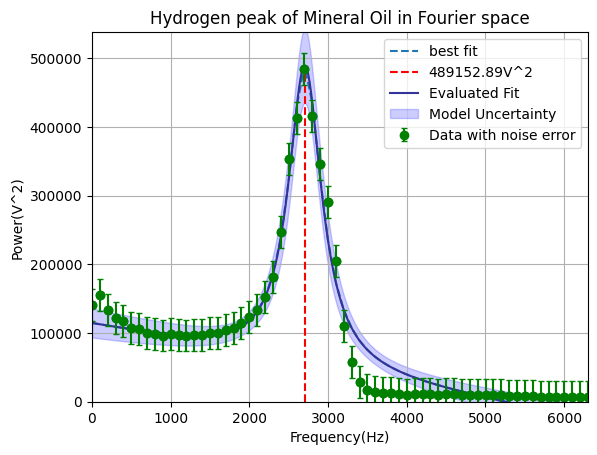

## Confidence Report:
Frequency is at 3764.5967211899206 Hz
{'max_freq': 3764.5967211899206, 'max_power': np.float64(540165.2705967976), 'result': <lmfit.model.ModelResult object at 0x000001DFDB1B1D10>, 'eval': array([ 8.16862265e+04,  8.15551220e+04,  8.14241472e+04,  8.12933036e+04,
        8.11625926e+04,  8.10320157e+04,  8.09015744e+04,  8.07712702e+04,
        8.06411046e+04,  8.05110793e+04,  8.03811958e+04,  8.02514557e+04,
        8.01218607e+04,  7.99924124e+04,  7.98631125e+04,  7.97339626e+04,
        7.96049647e+04,  7.94761203e+04,  7.93474312e+04,  7.92188993e+04,
        7.90905265e+04,  7.89623144e+04,  7.88342652e+04,  7.87063805e+04,
        7.85786625e+04,  7.84511130e+04,  7.83237341e+04,  7.81965278e+04,
        7.80694961e+04,  7.79426411e+04,  7.78159651e+04,  7.76894700e+04,
        7.75631581e+04,  7.74370316e+04,  7.73110928e+04,  7.71853439e+04,
        7.70597873e+04,  7.69344253e+04,  7.68092604e+04,  7.66842948e+04,
        7.65595312e+04,  7.64349720e+04

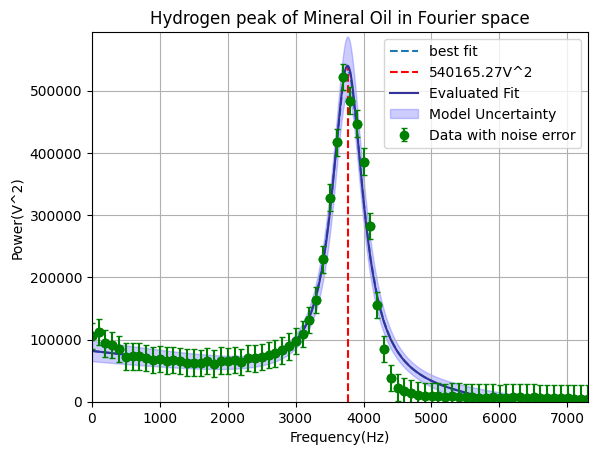

## Confidence Report:
Frequency is at 4809.324767117645 Hz
{'max_freq': 4809.324767117645, 'max_power': np.float64(596537.0001463558), 'result': <lmfit.model.ModelResult object at 0x000001DFD6FB39D0>, 'eval': array([ 4.80215378e+04,  4.79466252e+04,  4.78718551e+04,  4.77972290e+04,
        4.77227485e+04,  4.76484151e+04,  4.75742306e+04,  4.75001966e+04,
        4.74263147e+04,  4.73525867e+04,  4.72790143e+04,  4.72055991e+04,
        4.71323431e+04,  4.70592479e+04,  4.69863155e+04,  4.69135476e+04,
        4.68409461e+04,  4.67685129e+04,  4.66962500e+04,  4.66241593e+04,
        4.65522428e+04,  4.64805024e+04,  4.64089403e+04,  4.63375585e+04,
        4.62663591e+04,  4.61953443e+04,  4.61245161e+04,  4.60538768e+04,
        4.59834286e+04,  4.59131738e+04,  4.58431146e+04,  4.57732535e+04,
        4.57035926e+04,  4.56341345e+04,  4.55648816e+04,  4.54958362e+04,
        4.54270011e+04,  4.53583786e+04,  4.52899713e+04,  4.52217819e+04,
        4.51538131e+04,  4.50860675e+04, 

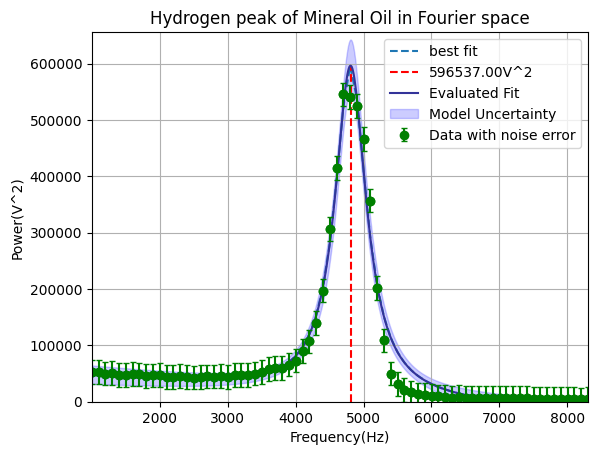

## Confidence Report:
Frequency is at 5838.9577475744245 Hz
{'max_freq': 5838.9577475744245, 'max_power': np.float64(604604.3762661413), 'result': <lmfit.model.ModelResult object at 0x000001DFD6FB02D0>, 'eval': array([ 2.75573505e+04,  2.75218214e+04,  2.74864680e+04,  2.74512922e+04,
        2.74162962e+04,  2.73814819e+04,  2.73468516e+04,  2.73124072e+04,
        2.72781511e+04,  2.72440854e+04,  2.72102124e+04,  2.71765342e+04,
        2.71430532e+04,  2.71097718e+04,  2.70766923e+04,  2.70438170e+04,
        2.70111485e+04,  2.69786892e+04,  2.69464416e+04,  2.69144083e+04,
        2.68825918e+04,  2.68509948e+04,  2.68196200e+04,  2.67884700e+04,
        2.67575476e+04,  2.67268556e+04,  2.66963967e+04,  2.66661740e+04,
        2.66361903e+04,  2.66064486e+04,  2.65769518e+04,  2.65477031e+04,
        2.65187055e+04,  2.64899622e+04,  2.64614765e+04,  2.64332515e+04,
        2.64052905e+04,  2.63775970e+04,  2.63501743e+04,  2.63230258e+04,
        2.62961552e+04,  2.62695660e+04

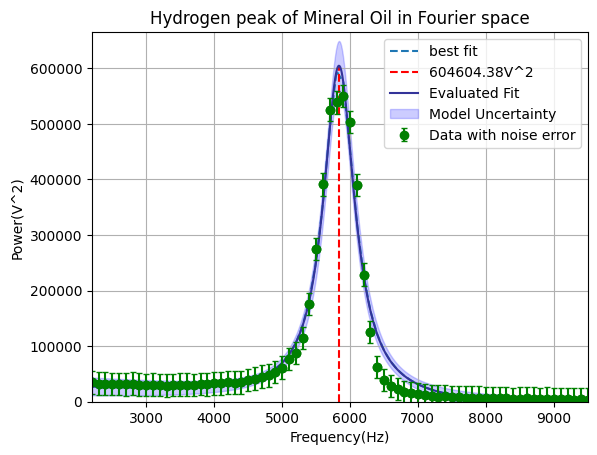

## Confidence Report:
Frequency is at 6902.417200778105 Hz
{'max_freq': 6902.417200778105, 'max_power': np.float64(602547.0851266888), 'result': <lmfit.model.ModelResult object at 0x000001DFD6FB0050>, 'eval': array([-9.30351594e+03, -9.27884429e+03, -9.25401763e+03, -9.22903419e+03,
       -9.20389219e+03, -9.17858982e+03, -9.15312526e+03, -9.12749664e+03,
       -9.10170208e+03, -9.07573966e+03, -9.04960744e+03, -9.02330345e+03,
       -8.99682571e+03, -8.97017217e+03, -8.94334079e+03, -8.91632947e+03,
       -8.88913611e+03, -8.86175855e+03, -8.83419461e+03, -8.80644209e+03,
       -8.77849874e+03, -8.75036227e+03, -8.72203039e+03, -8.69350073e+03,
       -8.66477093e+03, -8.63583855e+03, -8.60670116e+03, -8.57735624e+03,
       -8.54780129e+03, -8.51803372e+03, -8.48805094e+03, -8.45785028e+03,
       -8.42742908e+03, -8.39678458e+03, -8.36591404e+03, -8.33481462e+03,
       -8.30348347e+03, -8.27191769e+03, -8.24011433e+03, -8.20807039e+03,
       -8.17578283e+03, -8.14324856e+03, 

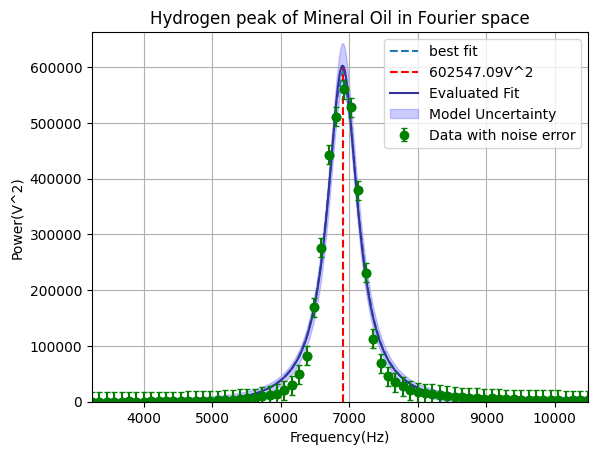

## Confidence Report:
Frequency is at 7890.333782948275 Hz
{'max_freq': 7890.333782948275, 'max_power': np.float64(523892.8444084606), 'result': <lmfit.model.ModelResult object at 0x000001DFD6FB2350>, 'eval': array([-5.91416544e+03, -5.89984973e+03, -5.88539980e+03, -5.87081412e+03,
       -5.85609117e+03, -5.84122939e+03, -5.82622719e+03, -5.81108298e+03,
       -5.79579514e+03, -5.78036201e+03, -5.76478193e+03, -5.74905319e+03,
       -5.73317409e+03, -5.71714288e+03, -5.70095778e+03, -5.68461700e+03,
       -5.66811872e+03, -5.65146110e+03, -5.63464225e+03, -5.61766028e+03,
       -5.60051325e+03, -5.58319920e+03, -5.56571614e+03, -5.54806207e+03,
       -5.53023492e+03, -5.51223261e+03, -5.49405305e+03, -5.47569408e+03,
       -5.45715353e+03, -5.43842919e+03, -5.41951883e+03, -5.40042016e+03,
       -5.38113088e+03, -5.36164863e+03, -5.34197105e+03, -5.32209570e+03,
       -5.30202014e+03, -5.28174187e+03, -5.26125835e+03, -5.24056702e+03,
       -5.21966526e+03, -5.19855041e+03, 

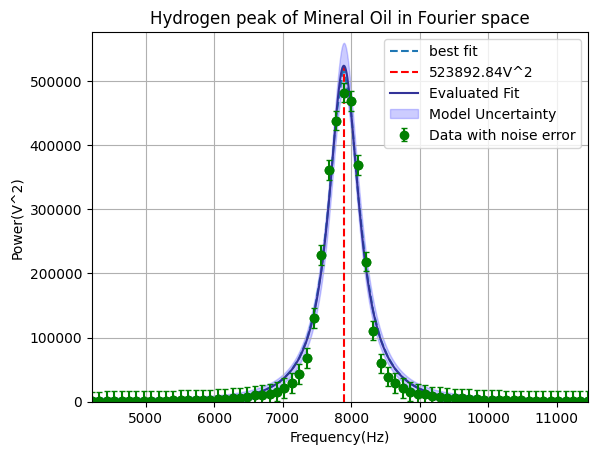

In [43]:

pulse_params= {"threshold_max":7.5, "threshold_min":6}
fft_params = {"initial_sigma": 5000, "num_points": 700, "sigma_levels": [1,2,3]}

fft_s1_list = get_fft_data(sample1, sample1out, pulse_params, fft_params, id = '_sample1')

### second sample 1

In [44]:
sample1_2filename = "pNMR2.5 FFT T2 data/Sick_aFIDS"
sample1_2, sample1_2out = get_filenames(sample1_2filename, extension='.csv')

This is the raw FID plot

0.0
0       0.06
1       0.06
2       0.00
3       0.00
4       0.00
        ... 
2494    0.00
2495    0.00
2496   -0.06
2497   -0.06
2498   -0.06
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



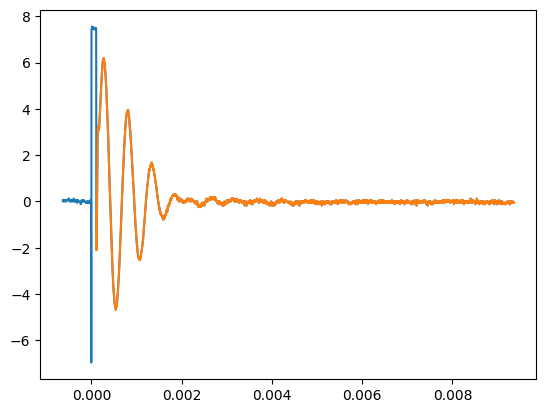

## Confidence Report:
Frequency is at 1816.6926656412513 Hz
{'max_freq': 1816.6926656412513, 'max_power': np.float64(468133.8378696291), 'result': <lmfit.model.ModelResult object at 0x000001DFD97942D0>, 'eval': array([ 1.54690983e+04,  1.55358371e+04,  1.56037286e+04,  1.56727916e+04,
        1.57430451e+04,  1.58145086e+04,  1.58872020e+04,  1.59611456e+04,
        1.60363600e+04,  1.61128663e+04,  1.61906861e+04,  1.62698413e+04,
        1.63503544e+04,  1.64322484e+04,  1.65155466e+04,  1.66002728e+04,
        1.66864516e+04,  1.67741078e+04,  1.68632668e+04,  1.69539546e+04,
        1.70461978e+04,  1.71400235e+04,  1.72354594e+04,  1.73325337e+04,
        1.74312755e+04,  1.75317143e+04,  1.76338802e+04,  1.77378041e+04,
        1.78435177e+04,  1.79510531e+04,  1.80604434e+04,  1.81717222e+04,
        1.82849241e+04,  1.84000843e+04,  1.85172389e+04,  1.86364248e+04,
        1.87576797e+04,  1.88810421e+04,  1.90065517e+04,  1.91342489e+04,
        1.92641749e+04,  1.93963721e+04

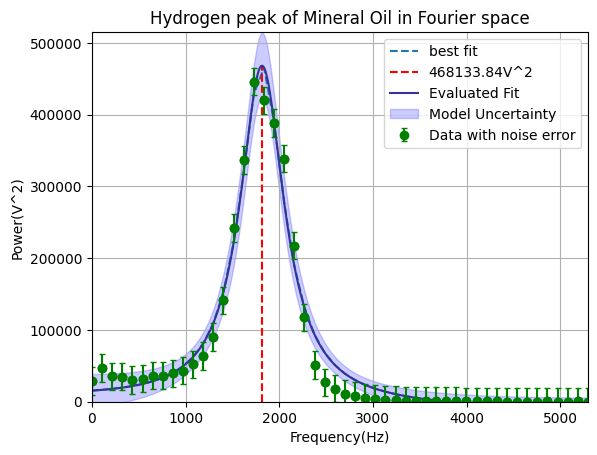

## Confidence Report:
Frequency is at 2706.438045905261 Hz
{'max_freq': 2706.438045905261, 'max_power': np.float64(489152.8880200373), 'result': <lmfit.model.ModelResult object at 0x000001DFD6EAD1D0>, 'eval': array([ 1.14668868e+05,  1.14497158e+05,  1.14325707e+05,  1.14154518e+05,
        1.13983594e+05,  1.13812939e+05,  1.13642557e+05,  1.13472451e+05,
        1.13302625e+05,  1.13133083e+05,  1.12963828e+05,  1.12794865e+05,
        1.12626197e+05,  1.12457829e+05,  1.12289765e+05,  1.12122008e+05,
        1.11954564e+05,  1.11787436e+05,  1.11620629e+05,  1.11454147e+05,
        1.11287996e+05,  1.11122179e+05,  1.10956702e+05,  1.10791568e+05,
        1.10626784e+05,  1.10462354e+05,  1.10298283e+05,  1.10134577e+05,
        1.09971240e+05,  1.09808278e+05,  1.09645697e+05,  1.09483502e+05,
        1.09321698e+05,  1.09160292e+05,  1.08999289e+05,  1.08838696e+05,
        1.08678517e+05,  1.08518761e+05,  1.08359432e+05,  1.08200538e+05,
        1.08042085e+05,  1.07884079e+05, 

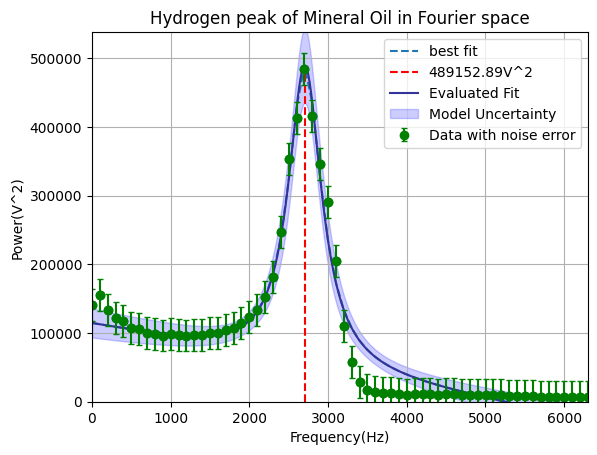

## Confidence Report:
Frequency is at 3764.5967211899206 Hz
{'max_freq': 3764.5967211899206, 'max_power': np.float64(540165.2705967976), 'result': <lmfit.model.ModelResult object at 0x000001DFD6EACF50>, 'eval': array([ 8.16862265e+04,  8.15551220e+04,  8.14241472e+04,  8.12933036e+04,
        8.11625926e+04,  8.10320157e+04,  8.09015744e+04,  8.07712702e+04,
        8.06411046e+04,  8.05110793e+04,  8.03811958e+04,  8.02514557e+04,
        8.01218607e+04,  7.99924124e+04,  7.98631125e+04,  7.97339626e+04,
        7.96049647e+04,  7.94761203e+04,  7.93474312e+04,  7.92188993e+04,
        7.90905265e+04,  7.89623144e+04,  7.88342652e+04,  7.87063805e+04,
        7.85786625e+04,  7.84511130e+04,  7.83237341e+04,  7.81965278e+04,
        7.80694961e+04,  7.79426411e+04,  7.78159651e+04,  7.76894700e+04,
        7.75631581e+04,  7.74370316e+04,  7.73110928e+04,  7.71853439e+04,
        7.70597873e+04,  7.69344253e+04,  7.68092604e+04,  7.66842948e+04,
        7.65595312e+04,  7.64349720e+04

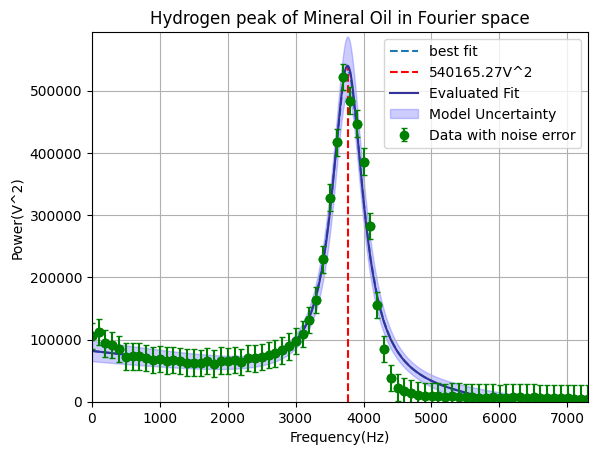

## Confidence Report:
Frequency is at 4809.324767117645 Hz
{'max_freq': 4809.324767117645, 'max_power': np.float64(596537.0001463558), 'result': <lmfit.model.ModelResult object at 0x000001DFD6EAF4D0>, 'eval': array([ 4.80215378e+04,  4.79466252e+04,  4.78718551e+04,  4.77972290e+04,
        4.77227485e+04,  4.76484151e+04,  4.75742306e+04,  4.75001966e+04,
        4.74263147e+04,  4.73525867e+04,  4.72790143e+04,  4.72055991e+04,
        4.71323431e+04,  4.70592479e+04,  4.69863155e+04,  4.69135476e+04,
        4.68409461e+04,  4.67685129e+04,  4.66962500e+04,  4.66241593e+04,
        4.65522428e+04,  4.64805024e+04,  4.64089403e+04,  4.63375585e+04,
        4.62663591e+04,  4.61953443e+04,  4.61245161e+04,  4.60538768e+04,
        4.59834286e+04,  4.59131738e+04,  4.58431146e+04,  4.57732535e+04,
        4.57035926e+04,  4.56341345e+04,  4.55648816e+04,  4.54958362e+04,
        4.54270011e+04,  4.53583786e+04,  4.52899713e+04,  4.52217819e+04,
        4.51538131e+04,  4.50860675e+04, 

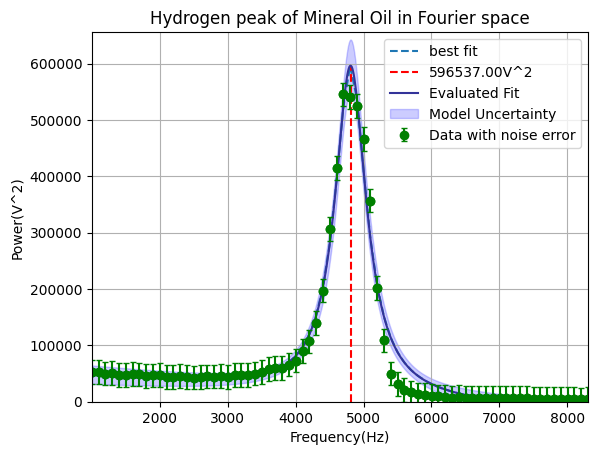

## Confidence Report:
Frequency is at 5838.9577475744245 Hz
{'max_freq': 5838.9577475744245, 'max_power': np.float64(604604.3762661413), 'result': <lmfit.model.ModelResult object at 0x000001DFD6EAF250>, 'eval': array([ 2.75573505e+04,  2.75218214e+04,  2.74864680e+04,  2.74512922e+04,
        2.74162962e+04,  2.73814819e+04,  2.73468516e+04,  2.73124072e+04,
        2.72781511e+04,  2.72440854e+04,  2.72102124e+04,  2.71765342e+04,
        2.71430532e+04,  2.71097718e+04,  2.70766923e+04,  2.70438170e+04,
        2.70111485e+04,  2.69786892e+04,  2.69464416e+04,  2.69144083e+04,
        2.68825918e+04,  2.68509948e+04,  2.68196200e+04,  2.67884700e+04,
        2.67575476e+04,  2.67268556e+04,  2.66963967e+04,  2.66661740e+04,
        2.66361903e+04,  2.66064486e+04,  2.65769518e+04,  2.65477031e+04,
        2.65187055e+04,  2.64899622e+04,  2.64614765e+04,  2.64332515e+04,
        2.64052905e+04,  2.63775970e+04,  2.63501743e+04,  2.63230258e+04,
        2.62961552e+04,  2.62695660e+04

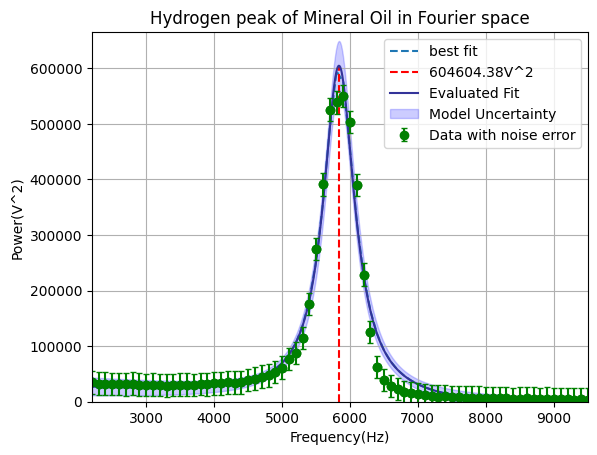

## Confidence Report:
Frequency is at 6902.417200778105 Hz
{'max_freq': 6902.417200778105, 'max_power': np.float64(602547.0851266888), 'result': <lmfit.model.ModelResult object at 0x000001DFDB1B1950>, 'eval': array([-9.30351594e+03, -9.27884429e+03, -9.25401763e+03, -9.22903419e+03,
       -9.20389219e+03, -9.17858982e+03, -9.15312526e+03, -9.12749664e+03,
       -9.10170208e+03, -9.07573966e+03, -9.04960744e+03, -9.02330345e+03,
       -8.99682571e+03, -8.97017217e+03, -8.94334079e+03, -8.91632947e+03,
       -8.88913611e+03, -8.86175855e+03, -8.83419461e+03, -8.80644209e+03,
       -8.77849874e+03, -8.75036227e+03, -8.72203039e+03, -8.69350073e+03,
       -8.66477093e+03, -8.63583855e+03, -8.60670116e+03, -8.57735624e+03,
       -8.54780129e+03, -8.51803372e+03, -8.48805094e+03, -8.45785028e+03,
       -8.42742908e+03, -8.39678458e+03, -8.36591404e+03, -8.33481462e+03,
       -8.30348347e+03, -8.27191769e+03, -8.24011433e+03, -8.20807039e+03,
       -8.17578283e+03, -8.14324856e+03, 

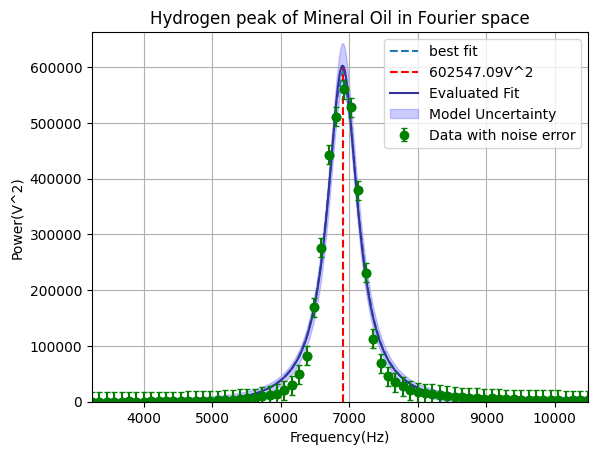

## Confidence Report:
Frequency is at 7890.333782948275 Hz
{'max_freq': 7890.333782948275, 'max_power': np.float64(523892.8444084606), 'result': <lmfit.model.ModelResult object at 0x000001DFDDFEEFD0>, 'eval': array([-5.91416544e+03, -5.89984973e+03, -5.88539980e+03, -5.87081412e+03,
       -5.85609117e+03, -5.84122939e+03, -5.82622719e+03, -5.81108298e+03,
       -5.79579514e+03, -5.78036201e+03, -5.76478193e+03, -5.74905319e+03,
       -5.73317409e+03, -5.71714288e+03, -5.70095778e+03, -5.68461700e+03,
       -5.66811872e+03, -5.65146110e+03, -5.63464225e+03, -5.61766028e+03,
       -5.60051325e+03, -5.58319920e+03, -5.56571614e+03, -5.54806207e+03,
       -5.53023492e+03, -5.51223261e+03, -5.49405305e+03, -5.47569408e+03,
       -5.45715353e+03, -5.43842919e+03, -5.41951883e+03, -5.40042016e+03,
       -5.38113088e+03, -5.36164863e+03, -5.34197105e+03, -5.32209570e+03,
       -5.30202014e+03, -5.28174187e+03, -5.26125835e+03, -5.24056702e+03,
       -5.21966526e+03, -5.19855041e+03, 

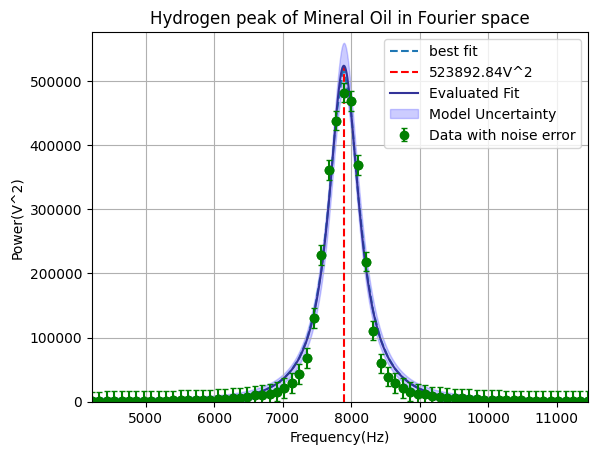

In [45]:

pulse_params= {"threshold_max":7.5, "threshold_min":6}
fft_params = {"initial_sigma": 5000, "num_points": 700, "sigma_levels": [1,2,3]}

fft_s1_2_list = get_fft_data(sample1_2, sample1_2out, pulse_params, fft_params, id = '_sample1_2')

## get width vs input frequency

In [46]:
print(len(fft_s1_list))

7


In [47]:
fft1_list = fft_s1_list + fft_s1_2_list

print(len(fft1_list))

14


e
e
e
e
e
e
e
e
e
e
e
e
e
e


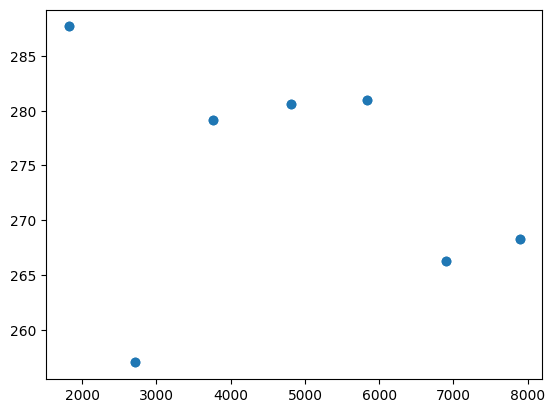

In [38]:

# print(fft_list)
fft_max_freq = []
fft_width = []
 # {'max_freq':new_max_freq, 'max_power':new_maxval, 'result': result, 'eval': y_random_fit, 'ci': ci}
for fft_data in fft1_list:
    print('e')
    fft_max_freq.append(fft_data['max_freq'])
    fft_width.append(fft_data['result'].params['sigma'].value)


plt.scatter(fft_max_freq, fft_width)
plt.show()


# Sample 2

### first sample 2 

This is the raw FID plot

0.0
0       0.06
1       0.06
2       0.00
3       0.00
4       0.00
        ... 
2494    0.00
2495    0.00
2496   -0.06
2497   -0.06
2498   -0.06
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



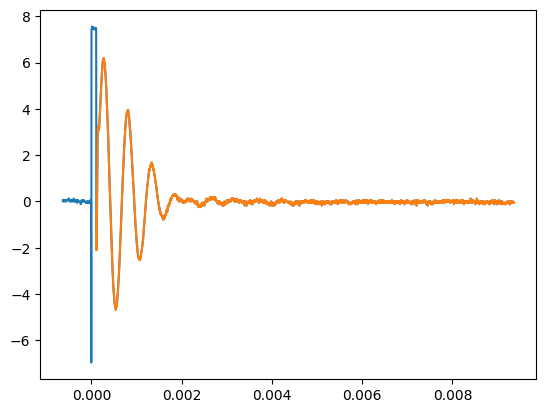

## Confidence Report:
Frequency is at 1816.6926656412513 Hz
{'max_freq': 1816.6926656412513, 'max_power': np.float64(468133.8378696291), 'result': <lmfit.model.ModelResult object at 0x000001DFD6F4E350>, 'eval': array([ 1.54690983e+04,  1.55358371e+04,  1.56037286e+04,  1.56727916e+04,
        1.57430451e+04,  1.58145086e+04,  1.58872020e+04,  1.59611456e+04,
        1.60363600e+04,  1.61128663e+04,  1.61906861e+04,  1.62698413e+04,
        1.63503544e+04,  1.64322484e+04,  1.65155466e+04,  1.66002728e+04,
        1.66864516e+04,  1.67741078e+04,  1.68632668e+04,  1.69539546e+04,
        1.70461978e+04,  1.71400235e+04,  1.72354594e+04,  1.73325337e+04,
        1.74312755e+04,  1.75317143e+04,  1.76338802e+04,  1.77378041e+04,
        1.78435177e+04,  1.79510531e+04,  1.80604434e+04,  1.81717222e+04,
        1.82849241e+04,  1.84000843e+04,  1.85172389e+04,  1.86364248e+04,
        1.87576797e+04,  1.88810421e+04,  1.90065517e+04,  1.91342489e+04,
        1.92641749e+04,  1.93963721e+04

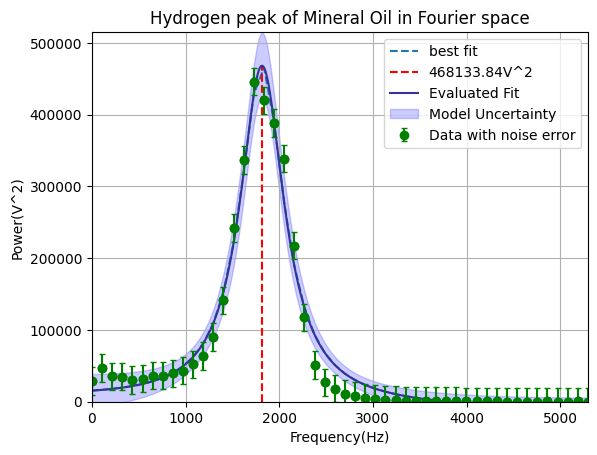

## Confidence Report:
Frequency is at 2706.438045905261 Hz
{'max_freq': 2706.438045905261, 'max_power': np.float64(489152.8880200373), 'result': <lmfit.model.ModelResult object at 0x000001DFD70D3750>, 'eval': array([ 1.14668868e+05,  1.14497158e+05,  1.14325707e+05,  1.14154518e+05,
        1.13983594e+05,  1.13812939e+05,  1.13642557e+05,  1.13472451e+05,
        1.13302625e+05,  1.13133083e+05,  1.12963828e+05,  1.12794865e+05,
        1.12626197e+05,  1.12457829e+05,  1.12289765e+05,  1.12122008e+05,
        1.11954564e+05,  1.11787436e+05,  1.11620629e+05,  1.11454147e+05,
        1.11287996e+05,  1.11122179e+05,  1.10956702e+05,  1.10791568e+05,
        1.10626784e+05,  1.10462354e+05,  1.10298283e+05,  1.10134577e+05,
        1.09971240e+05,  1.09808278e+05,  1.09645697e+05,  1.09483502e+05,
        1.09321698e+05,  1.09160292e+05,  1.08999289e+05,  1.08838696e+05,
        1.08678517e+05,  1.08518761e+05,  1.08359432e+05,  1.08200538e+05,
        1.08042085e+05,  1.07884079e+05, 

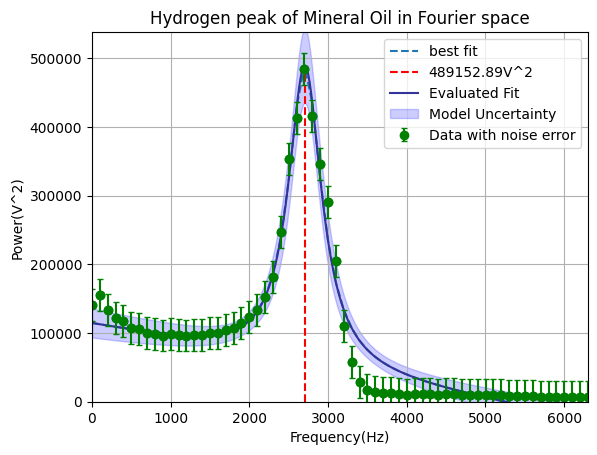

## Confidence Report:
Frequency is at 3764.5967211899206 Hz
{'max_freq': 3764.5967211899206, 'max_power': np.float64(540165.2705967976), 'result': <lmfit.model.ModelResult object at 0x000001DFD70D1BD0>, 'eval': array([ 8.16862265e+04,  8.15551220e+04,  8.14241472e+04,  8.12933036e+04,
        8.11625926e+04,  8.10320157e+04,  8.09015744e+04,  8.07712702e+04,
        8.06411046e+04,  8.05110793e+04,  8.03811958e+04,  8.02514557e+04,
        8.01218607e+04,  7.99924124e+04,  7.98631125e+04,  7.97339626e+04,
        7.96049647e+04,  7.94761203e+04,  7.93474312e+04,  7.92188993e+04,
        7.90905265e+04,  7.89623144e+04,  7.88342652e+04,  7.87063805e+04,
        7.85786625e+04,  7.84511130e+04,  7.83237341e+04,  7.81965278e+04,
        7.80694961e+04,  7.79426411e+04,  7.78159651e+04,  7.76894700e+04,
        7.75631581e+04,  7.74370316e+04,  7.73110928e+04,  7.71853439e+04,
        7.70597873e+04,  7.69344253e+04,  7.68092604e+04,  7.66842948e+04,
        7.65595312e+04,  7.64349720e+04

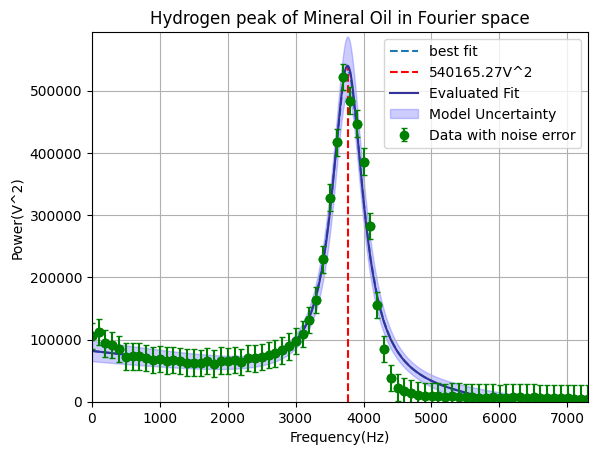

## Confidence Report:
Frequency is at 4809.324767117645 Hz
{'max_freq': 4809.324767117645, 'max_power': np.float64(596537.0001463558), 'result': <lmfit.model.ModelResult object at 0x000001DFD70D3610>, 'eval': array([ 4.80215378e+04,  4.79466252e+04,  4.78718551e+04,  4.77972290e+04,
        4.77227485e+04,  4.76484151e+04,  4.75742306e+04,  4.75001966e+04,
        4.74263147e+04,  4.73525867e+04,  4.72790143e+04,  4.72055991e+04,
        4.71323431e+04,  4.70592479e+04,  4.69863155e+04,  4.69135476e+04,
        4.68409461e+04,  4.67685129e+04,  4.66962500e+04,  4.66241593e+04,
        4.65522428e+04,  4.64805024e+04,  4.64089403e+04,  4.63375585e+04,
        4.62663591e+04,  4.61953443e+04,  4.61245161e+04,  4.60538768e+04,
        4.59834286e+04,  4.59131738e+04,  4.58431146e+04,  4.57732535e+04,
        4.57035926e+04,  4.56341345e+04,  4.55648816e+04,  4.54958362e+04,
        4.54270011e+04,  4.53583786e+04,  4.52899713e+04,  4.52217819e+04,
        4.51538131e+04,  4.50860675e+04, 

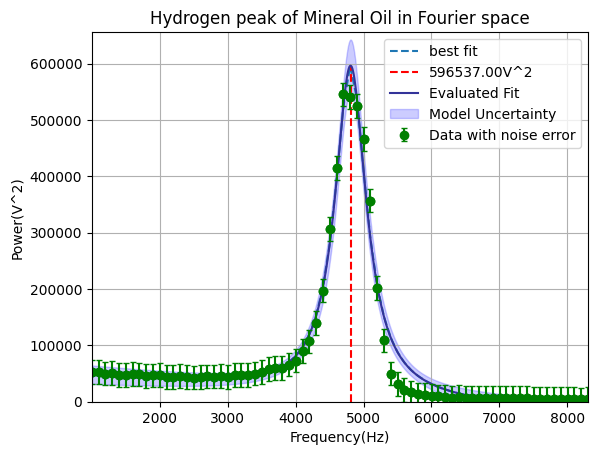

## Confidence Report:
Frequency is at 5838.9577475744245 Hz
{'max_freq': 5838.9577475744245, 'max_power': np.float64(604604.3762661413), 'result': <lmfit.model.ModelResult object at 0x000001DFD70D1E50>, 'eval': array([ 2.75573505e+04,  2.75218214e+04,  2.74864680e+04,  2.74512922e+04,
        2.74162962e+04,  2.73814819e+04,  2.73468516e+04,  2.73124072e+04,
        2.72781511e+04,  2.72440854e+04,  2.72102124e+04,  2.71765342e+04,
        2.71430532e+04,  2.71097718e+04,  2.70766923e+04,  2.70438170e+04,
        2.70111485e+04,  2.69786892e+04,  2.69464416e+04,  2.69144083e+04,
        2.68825918e+04,  2.68509948e+04,  2.68196200e+04,  2.67884700e+04,
        2.67575476e+04,  2.67268556e+04,  2.66963967e+04,  2.66661740e+04,
        2.66361903e+04,  2.66064486e+04,  2.65769518e+04,  2.65477031e+04,
        2.65187055e+04,  2.64899622e+04,  2.64614765e+04,  2.64332515e+04,
        2.64052905e+04,  2.63775970e+04,  2.63501743e+04,  2.63230258e+04,
        2.62961552e+04,  2.62695660e+04

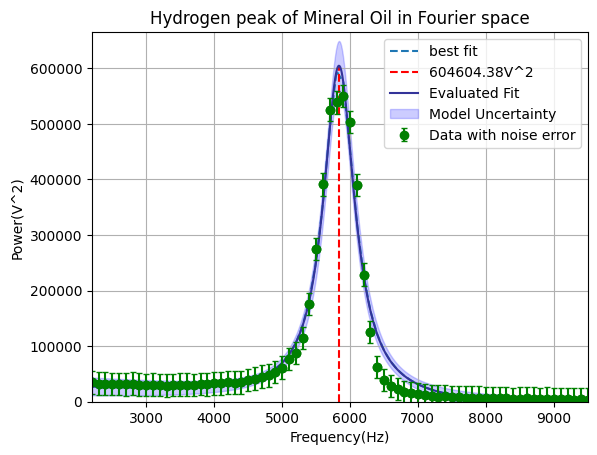

## Confidence Report:
Frequency is at 6902.417200778105 Hz
{'max_freq': 6902.417200778105, 'max_power': np.float64(602547.0851266888), 'result': <lmfit.model.ModelResult object at 0x000001DFD6EAFD90>, 'eval': array([-9.30351594e+03, -9.27884429e+03, -9.25401763e+03, -9.22903419e+03,
       -9.20389219e+03, -9.17858982e+03, -9.15312526e+03, -9.12749664e+03,
       -9.10170208e+03, -9.07573966e+03, -9.04960744e+03, -9.02330345e+03,
       -8.99682571e+03, -8.97017217e+03, -8.94334079e+03, -8.91632947e+03,
       -8.88913611e+03, -8.86175855e+03, -8.83419461e+03, -8.80644209e+03,
       -8.77849874e+03, -8.75036227e+03, -8.72203039e+03, -8.69350073e+03,
       -8.66477093e+03, -8.63583855e+03, -8.60670116e+03, -8.57735624e+03,
       -8.54780129e+03, -8.51803372e+03, -8.48805094e+03, -8.45785028e+03,
       -8.42742908e+03, -8.39678458e+03, -8.36591404e+03, -8.33481462e+03,
       -8.30348347e+03, -8.27191769e+03, -8.24011433e+03, -8.20807039e+03,
       -8.17578283e+03, -8.14324856e+03, 

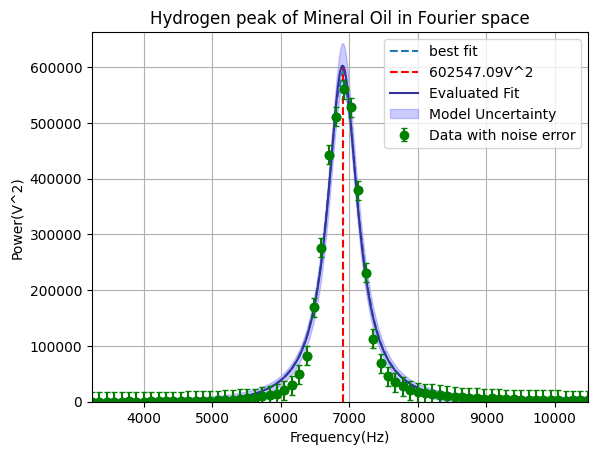

## Confidence Report:
Frequency is at 7890.333782948275 Hz
{'max_freq': 7890.333782948275, 'max_power': np.float64(523892.8444084606), 'result': <lmfit.model.ModelResult object at 0x000001DFD6EADD10>, 'eval': array([-5.91416544e+03, -5.89984973e+03, -5.88539980e+03, -5.87081412e+03,
       -5.85609117e+03, -5.84122939e+03, -5.82622719e+03, -5.81108298e+03,
       -5.79579514e+03, -5.78036201e+03, -5.76478193e+03, -5.74905319e+03,
       -5.73317409e+03, -5.71714288e+03, -5.70095778e+03, -5.68461700e+03,
       -5.66811872e+03, -5.65146110e+03, -5.63464225e+03, -5.61766028e+03,
       -5.60051325e+03, -5.58319920e+03, -5.56571614e+03, -5.54806207e+03,
       -5.53023492e+03, -5.51223261e+03, -5.49405305e+03, -5.47569408e+03,
       -5.45715353e+03, -5.43842919e+03, -5.41951883e+03, -5.40042016e+03,
       -5.38113088e+03, -5.36164863e+03, -5.34197105e+03, -5.32209570e+03,
       -5.30202014e+03, -5.28174187e+03, -5.26125835e+03, -5.24056702e+03,
       -5.21966526e+03, -5.19855041e+03, 

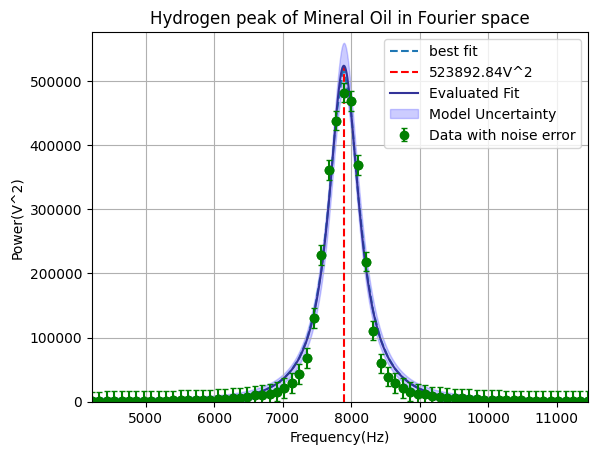

In [50]:

pulse_params= {"threshold_max":7.5, "threshold_min":6}
fft_params = {"initial_sigma": 5000, "num_points": 700, "sigma_levels": [1,2,3]}

sample2filename = "pNMR 2.26 final data FID/SAMPLE2"
sample2, sample2out = get_filenames(sample2filename, extension='.csv')

fft_s2_list = get_fft_data(sample2, sample2out, pulse_params, fft_params, id = '_sample2', plot=True)

### second sample 2

This is the raw FID plot

0.0
0       0.06
1       0.06
2       0.00
3       0.00
4       0.00
        ... 
2494    0.00
2495    0.00
2496   -0.06
2497   -0.06
2498   -0.06
Name: channel_1, Length: 2499, dtype: float64
this is the chopped plot



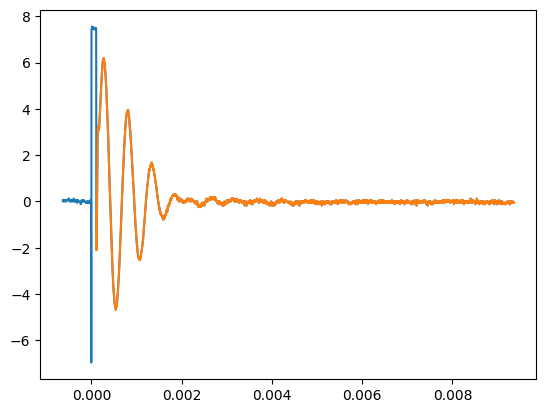

## Confidence Report:
Frequency is at 1816.6926656412513 Hz
{'max_freq': 1816.6926656412513, 'max_power': np.float64(468133.8378696291), 'result': <lmfit.model.ModelResult object at 0x000001DFDBB38690>, 'eval': array([ 1.54690983e+04,  1.55358371e+04,  1.56037286e+04,  1.56727916e+04,
        1.57430451e+04,  1.58145086e+04,  1.58872020e+04,  1.59611456e+04,
        1.60363600e+04,  1.61128663e+04,  1.61906861e+04,  1.62698413e+04,
        1.63503544e+04,  1.64322484e+04,  1.65155466e+04,  1.66002728e+04,
        1.66864516e+04,  1.67741078e+04,  1.68632668e+04,  1.69539546e+04,
        1.70461978e+04,  1.71400235e+04,  1.72354594e+04,  1.73325337e+04,
        1.74312755e+04,  1.75317143e+04,  1.76338802e+04,  1.77378041e+04,
        1.78435177e+04,  1.79510531e+04,  1.80604434e+04,  1.81717222e+04,
        1.82849241e+04,  1.84000843e+04,  1.85172389e+04,  1.86364248e+04,
        1.87576797e+04,  1.88810421e+04,  1.90065517e+04,  1.91342489e+04,
        1.92641749e+04,  1.93963721e+04

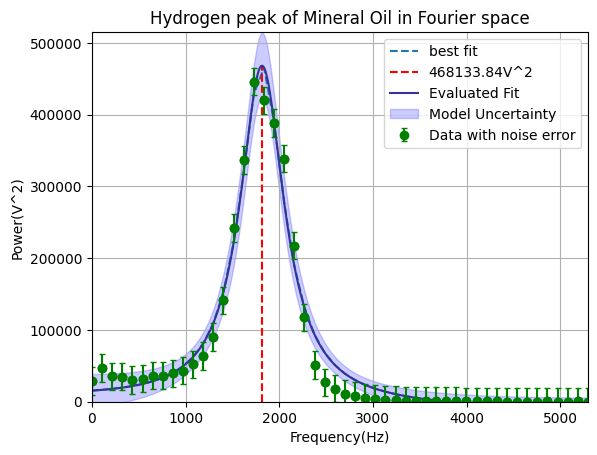

## Confidence Report:
Frequency is at 2706.438045905261 Hz
{'max_freq': 2706.438045905261, 'max_power': np.float64(489152.8880200373), 'result': <lmfit.model.ModelResult object at 0x000001DFD70D3890>, 'eval': array([ 1.14668868e+05,  1.14497158e+05,  1.14325707e+05,  1.14154518e+05,
        1.13983594e+05,  1.13812939e+05,  1.13642557e+05,  1.13472451e+05,
        1.13302625e+05,  1.13133083e+05,  1.12963828e+05,  1.12794865e+05,
        1.12626197e+05,  1.12457829e+05,  1.12289765e+05,  1.12122008e+05,
        1.11954564e+05,  1.11787436e+05,  1.11620629e+05,  1.11454147e+05,
        1.11287996e+05,  1.11122179e+05,  1.10956702e+05,  1.10791568e+05,
        1.10626784e+05,  1.10462354e+05,  1.10298283e+05,  1.10134577e+05,
        1.09971240e+05,  1.09808278e+05,  1.09645697e+05,  1.09483502e+05,
        1.09321698e+05,  1.09160292e+05,  1.08999289e+05,  1.08838696e+05,
        1.08678517e+05,  1.08518761e+05,  1.08359432e+05,  1.08200538e+05,
        1.08042085e+05,  1.07884079e+05, 

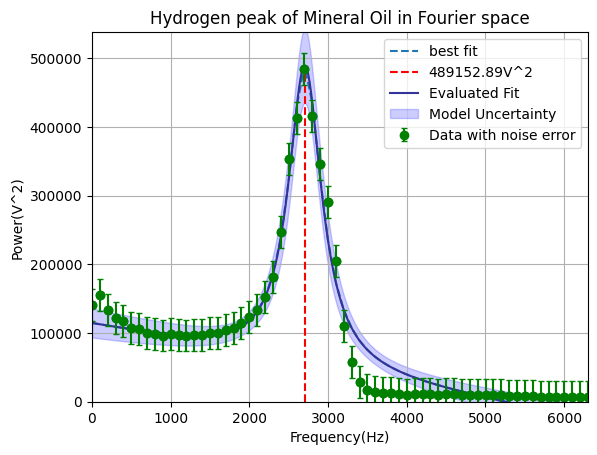

## Confidence Report:
Frequency is at 3764.5967211899206 Hz
{'max_freq': 3764.5967211899206, 'max_power': np.float64(540165.2705967976), 'result': <lmfit.model.ModelResult object at 0x000001DFD70D1450>, 'eval': array([ 8.16862265e+04,  8.15551220e+04,  8.14241472e+04,  8.12933036e+04,
        8.11625926e+04,  8.10320157e+04,  8.09015744e+04,  8.07712702e+04,
        8.06411046e+04,  8.05110793e+04,  8.03811958e+04,  8.02514557e+04,
        8.01218607e+04,  7.99924124e+04,  7.98631125e+04,  7.97339626e+04,
        7.96049647e+04,  7.94761203e+04,  7.93474312e+04,  7.92188993e+04,
        7.90905265e+04,  7.89623144e+04,  7.88342652e+04,  7.87063805e+04,
        7.85786625e+04,  7.84511130e+04,  7.83237341e+04,  7.81965278e+04,
        7.80694961e+04,  7.79426411e+04,  7.78159651e+04,  7.76894700e+04,
        7.75631581e+04,  7.74370316e+04,  7.73110928e+04,  7.71853439e+04,
        7.70597873e+04,  7.69344253e+04,  7.68092604e+04,  7.66842948e+04,
        7.65595312e+04,  7.64349720e+04

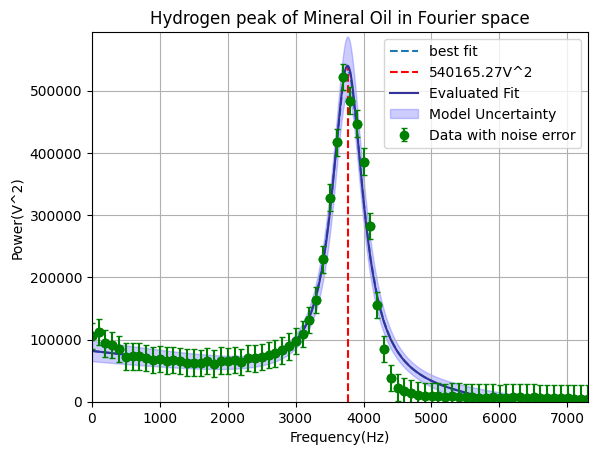

## Confidence Report:
Frequency is at 4809.324767117645 Hz
{'max_freq': 4809.324767117645, 'max_power': np.float64(596537.0001463558), 'result': <lmfit.model.ModelResult object at 0x000001DFDDFEC410>, 'eval': array([ 4.80215378e+04,  4.79466252e+04,  4.78718551e+04,  4.77972290e+04,
        4.77227485e+04,  4.76484151e+04,  4.75742306e+04,  4.75001966e+04,
        4.74263147e+04,  4.73525867e+04,  4.72790143e+04,  4.72055991e+04,
        4.71323431e+04,  4.70592479e+04,  4.69863155e+04,  4.69135476e+04,
        4.68409461e+04,  4.67685129e+04,  4.66962500e+04,  4.66241593e+04,
        4.65522428e+04,  4.64805024e+04,  4.64089403e+04,  4.63375585e+04,
        4.62663591e+04,  4.61953443e+04,  4.61245161e+04,  4.60538768e+04,
        4.59834286e+04,  4.59131738e+04,  4.58431146e+04,  4.57732535e+04,
        4.57035926e+04,  4.56341345e+04,  4.55648816e+04,  4.54958362e+04,
        4.54270011e+04,  4.53583786e+04,  4.52899713e+04,  4.52217819e+04,
        4.51538131e+04,  4.50860675e+04, 

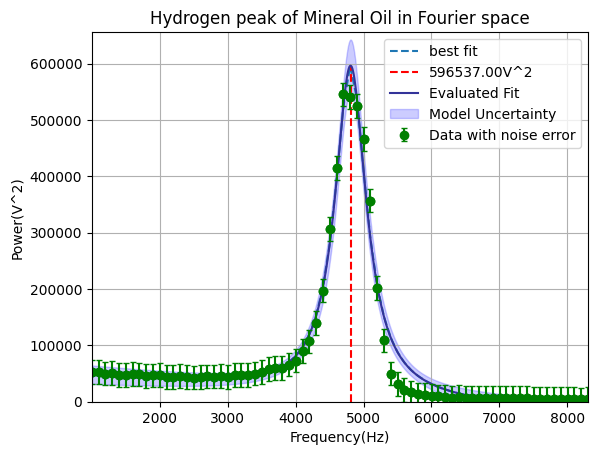

## Confidence Report:
Frequency is at 5838.9577475744245 Hz
{'max_freq': 5838.9577475744245, 'max_power': np.float64(604604.3762661413), 'result': <lmfit.model.ModelResult object at 0x000001DFD92602D0>, 'eval': array([ 2.75573505e+04,  2.75218214e+04,  2.74864680e+04,  2.74512922e+04,
        2.74162962e+04,  2.73814819e+04,  2.73468516e+04,  2.73124072e+04,
        2.72781511e+04,  2.72440854e+04,  2.72102124e+04,  2.71765342e+04,
        2.71430532e+04,  2.71097718e+04,  2.70766923e+04,  2.70438170e+04,
        2.70111485e+04,  2.69786892e+04,  2.69464416e+04,  2.69144083e+04,
        2.68825918e+04,  2.68509948e+04,  2.68196200e+04,  2.67884700e+04,
        2.67575476e+04,  2.67268556e+04,  2.66963967e+04,  2.66661740e+04,
        2.66361903e+04,  2.66064486e+04,  2.65769518e+04,  2.65477031e+04,
        2.65187055e+04,  2.64899622e+04,  2.64614765e+04,  2.64332515e+04,
        2.64052905e+04,  2.63775970e+04,  2.63501743e+04,  2.63230258e+04,
        2.62961552e+04,  2.62695660e+04

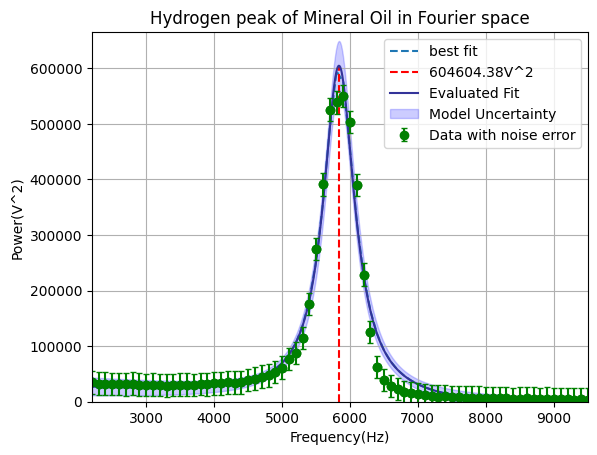

## Confidence Report:
Frequency is at 6902.417200778105 Hz
{'max_freq': 6902.417200778105, 'max_power': np.float64(602547.0851266888), 'result': <lmfit.model.ModelResult object at 0x000001DFD929BED0>, 'eval': array([-9.30351594e+03, -9.27884429e+03, -9.25401763e+03, -9.22903419e+03,
       -9.20389219e+03, -9.17858982e+03, -9.15312526e+03, -9.12749664e+03,
       -9.10170208e+03, -9.07573966e+03, -9.04960744e+03, -9.02330345e+03,
       -8.99682571e+03, -8.97017217e+03, -8.94334079e+03, -8.91632947e+03,
       -8.88913611e+03, -8.86175855e+03, -8.83419461e+03, -8.80644209e+03,
       -8.77849874e+03, -8.75036227e+03, -8.72203039e+03, -8.69350073e+03,
       -8.66477093e+03, -8.63583855e+03, -8.60670116e+03, -8.57735624e+03,
       -8.54780129e+03, -8.51803372e+03, -8.48805094e+03, -8.45785028e+03,
       -8.42742908e+03, -8.39678458e+03, -8.36591404e+03, -8.33481462e+03,
       -8.30348347e+03, -8.27191769e+03, -8.24011433e+03, -8.20807039e+03,
       -8.17578283e+03, -8.14324856e+03, 

IndexError: list index out of range

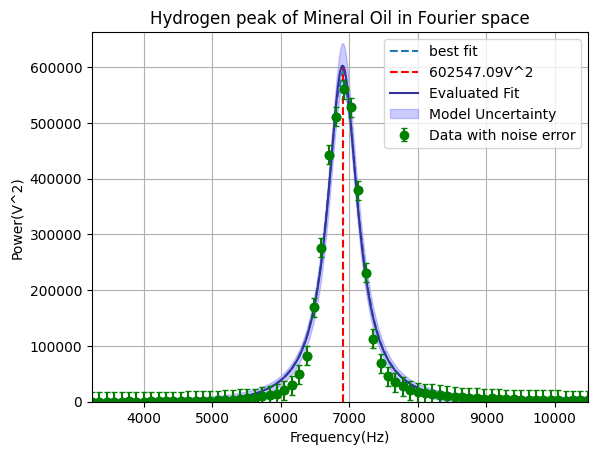

In [53]:
sample2_2filename = "2.10 Data Sample 2/FIDs"
sample2_2, sample2_2out = get_filenames(sample2_2filename, extension='.csv')

pulse_params= {"threshold_max":7.5, "threshold_min":6}
fft_params = {"initial_sigma": 5000, "num_points": 700, "sigma_levels": [1,2,3]}

fft_s2_2_list = get_fft_data(sample2_2, sample2_2out, pulse_params, fft_params, id = '_sample2_2')